In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
df = pd.read_csv("ecommerceDataset.csv")
df

,Household,"Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set of 4 Painting made up in synthetic frame with uv textured print which gives multi effects and attracts towards it. This is an special series of paintings which makes your wall very beautiful and gives a royal touch. This painting is ready to hang, you would be proud to possess this unique painting that is a niche apart. We use only the most modern and efficient printing technology on our prints, with only the and inks and precision epson, roland and hp printers. This innovative hd printing technique results in durable and spectacular looking prints of the highest that last a lifetime. We print solely with top-notch 100% inks, to achieve brilliant and true colours. Due to their high level of uv resistance, our prints retain their beautiful colours for many years. Add colour and style to your living space with this digitally printed painting. Some are for pleasure and some for eternal bliss.so bring home this elegant print that is lushed with rich colors that makes it nothing but sheer elegance to be to your friends and family.it would be treasured forever by whoever your lucky recipient is. Liven up your place with these intriguing paintings that are high definition hd graphic digital prints for home, office or any room."
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
3,Household,Incredible Gifts India Wooden Happy Birthday U...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...
...,...,...
50419,Electronics,Strontium MicroSD Class 10 8GB Memory Card (Bl...
50420,Electronics,CrossBeats Wave Waterproof Bluetooth Wireless ...
50421,Electronics,Karbonn Titanium Wind W4 (White) Karbonn Titan...
50422,Electronics,"Samsung Guru FM Plus (SM-B110E/D, Black) Colou..."


In [3]:
df.shape

(50424, 2)

In [4]:
df.isna().sum()

Household                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

In [5]:
df.duplicated().sum()

22622

In [6]:
df = df.drop_duplicates()

In [7]:
df.duplicated().sum()

0

In [8]:
# Rename
df.columns = ['Type', 'Comments']

In [9]:
df.head()

,Type,Comments
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
3,Household,Incredible Gifts India Wooden Happy Birthday U...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...


In [10]:
df.isna().sum()

Type        0
Comments    1
dtype: int64

In [11]:
df.Type.value_counts()

Type
Household                 10563
Books                      6256
Clothing & Accessories     5675
Electronics                5308
Name: count, dtype: int64

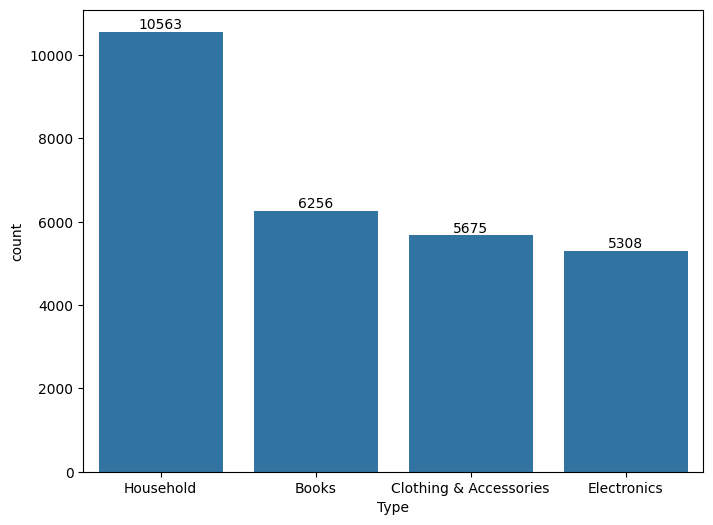

In [12]:
plt.figure(figsize=(8,6))

ax = sns.countplot(x=df.Type)

for bar in ax.patches:
    height = bar.get_height()
    
    ax.annotate(f"{int(height)}",
                (bar.get_x() + bar.get_width() / 2, height),
                ha='center',
                va='bottom')

plt.show()

In [13]:
df.head(10)

,Type,Comments
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
3,Household,Incredible Gifts India Wooden Happy Birthday U...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...
5,Household,Paper Plane Design Starry Night Vangoh Wall Ar...
7,Household,SAF 'Ganesh Modern Art Print' Painting (Synthe...
8,Household,Paintings Villa UV Textured Modern Art Print F...
9,Household,Painting Mantra Art Street - Jardin Bird Frame...
12,Household,Painting Mantra 'Vintage Car' Art Printing Set...


In [14]:
df.head()

,Type,Comments
0,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
1,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
2,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
3,Household,Incredible Gifts India Wooden Happy Birthday U...
4,Household,Pitaara Box Romantic Venice Canvas Painting 6m...


In [16]:
import pandas as pd
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

def clean_text(text):

    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    rem_pun = text.translate(str.maketrans('', '', string.punctuation))

    # Remove digits
    rem_digits = rem_pun.translate(str.maketrans('', '', string.digits))

    # Tokenize into words
    words_split = rem_digits.split()

    # Remove stopwords
    en_stop_words = set(stopwords.words('english'))
    rem_stop_words = [word for word in words_split if word not in en_stop_words]

    # Lemmatization
    lemma = WordNetLemmatizer()
    lemmatized_words = [lemma.lemmatize(word) for word in rem_stop_words]

    # Join words
    pure_text = " ".join(lemmatized_words)

    return pure_text


df['Comments'] = df['Comments'].apply(clean_text)

C:\Users\Qbits\AppData\Local\Temp\ipykernel_5364\2028277306.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Comments'] = df['Comments'].apply(clean_text)


In [17]:
df.head()

,Type,Comments
0,Household,saf floral framed painting wood inch x inch sp...
1,Household,saf uv textured modern art print framed painti...
2,Household,saf flower print framed painting synthetic inc...
3,Household,incredible gift india wooden happy birthday un...
4,Household,pitaara box romantic venice canvas painting mm...


In [18]:
x = df['Comments']
y = df['Type']

In [19]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size = 0.2, random_state = 420)

In [20]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
vector = TfidfVectorizer(analyzer=clean_text)
tf_train = vector.fit_transform(xtrain)
tf_test = vector.transform(xtest)

In [21]:
tf_train.toarray()

array([[0.4015302 , 0.08082765, 0.08768703, ..., 0.        , 0.        ,
        0.        ],
       [0.5007464 , 0.26068909, 0.05656245, ..., 0.        , 0.        ,
        0.        ],
       [0.52003178, 0.13957588, 0.15142087, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.47948886, 0.28151859, 0.08725984, ..., 0.        , 0.        ,
        0.        ],
       [0.57748867, 0.2131212 , 0.06305661, ..., 0.        , 0.        ,
        0.        ],
       [0.45186782, 0.36734076, 0.06641914, ..., 0.        , 0.        ,
        0.        ]])

In [22]:
tf_test.toarray()

array([[0.38444357, 0.12898022, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.52142893, 0.2296069 , 0.06405231, ..., 0.        , 0.        ,
        0.        ],
       [0.54045401, 0.32310669, 0.05324459, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.54798265, 0.22470229, 0.03693507, ..., 0.        , 0.        ,
        0.        ],
       [0.51862711, 0.2348981 , 0.02831472, ..., 0.        , 0.        ,
        0.        ],
       [0.52219537, 0.20566456, 0.05784544, ..., 0.        , 0.        ,
        0.        ]])

In [23]:
from sklearn.linear_model import LogisticRegression
import warnings 
warnings.filterwarnings('ignore')
lr = LogisticRegression()
lr.fit(tf_train, ytrain)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
train_Score = lr.score(tf_train, ytrain)
train_Score

0.59448765792905

In [25]:
test_score = lr.score(tf_test, ytest)
test_score

0.5819097284661032

In [26]:
predict = lr.predict(tf_test)
predict

array(['Books', 'Household', 'Household', ..., 'Household', 'Household',
       'Household'], dtype=object)

In [27]:
df.head()

,Type,Comments
0,Household,saf floral framed painting wood inch x inch sp...
1,Household,saf uv textured modern art print framed painti...
2,Household,saf flower print framed painting synthetic inc...
3,Household,incredible gift india wooden happy birthday un...
4,Household,pitaara box romantic venice canvas painting mm...


In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [29]:
print("Accuracy score: ", accuracy_score(ytest, predict))

Accuracy score:  0.5819097284661032


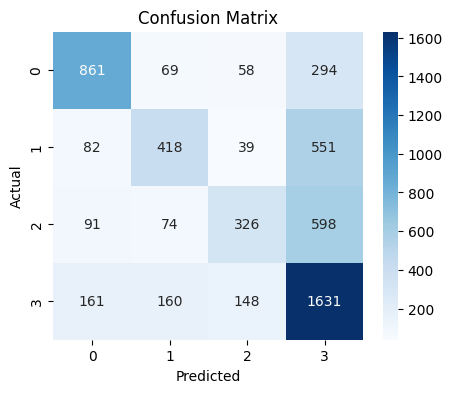

In [30]:
plt.figure(figsize=(5,4))
cm = confusion_matrix(ytest, predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

In [31]:
y_prob = lr.predict_proba(tf_test)[:, 1]

In [32]:
print(set(ytest))

{'Electronics', 'Clothing & Accessories', 'Books', 'Household'}


In [33]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

In [34]:
classes = np.unique(ytest)
ytest_bin = label_binarize(ytest, classes=classes)

In [35]:
y_score = lr.predict_proba(tf_test)

In [36]:
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(ytest_bin[:, i], y_score[:, i]) # roc_curve(actual_values, predicted_probabilities)
    roc_auc[i] = auc(fpr[i], tpr[i])

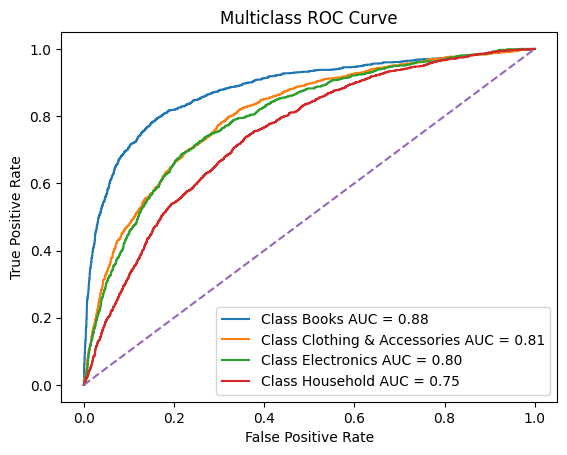

In [37]:
import matplotlib.pyplot as plt

plt.figure()

for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {classes[i]} AUC = {roc_auc[i]:.2f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()